In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import yfinance as yf

from datetime import datetime

from sklearn.model_selection import (train_test_split,
                                     GridSearchCV ,
                                     cross_validate , 
                                     cross_val_predict,
                                     cross_val_score,
                                     TimeSeriesSplit,)


from sklearn.preprocessing import (StandardScaler,
                                   MinMaxScaler,
                                   OneHotEncoder,
                                   LabelEncoder,
                                   PolynomialFeatures)


from sklearn.metrics import (classification_report,
                             f1_score,
                             r2_score,
                             recall_score ,
                             precision_score ,
                             mean_squared_error , 
                             mean_absolute_error ,
                             root_mean_squared_error,
                             confusion_matrix)

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.decomposition import PCA

from umap import UMAP

from sklearn.manifold import TSNE

from sklearn.linear_model import Lasso, Ridge , ElasticNet

from sklearn.svm import SVC , SVR

from sklearn.neighbors import KNeighborsClassifier , KNeighborsRegressor

from sklearn.ensemble import (RandomForestClassifier,
                              RandomForestRegressor,
                              AdaBoostClassifier ,
                              AdaBoostRegressor ,
                              GradientBoostingClassifier,
                              GradientBoostingRegressor,
                              AdaBoostClassifier,)
from sklearn.pipeline import Pipeline

from xgboost import  XGBRegressor, XGBClassifier

In [121]:
start = "2023-01-01"
today = datetime.today().strftime("%Y-%m-%d")
data = yf.download("AAPL", start= start, end="2025-01-01" ,auto_adjust=True)
data.to_csv('apple_stock.csv')
print(data.columns.get_level_values(1))
print(data.columns.get_level_values(0))
data.head()

[*********************100%***********************]  1 of 1 completed

Index(['AAPL', 'AAPL', 'AAPL', 'AAPL', 'AAPL'], dtype='object', name='Ticker')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.330650,129.079567,122.443165,128.468194,112117500
2023-01-04,124.602715,126.870731,123.340517,125.125343,89113600
2023-01-05,123.281334,125.993089,123.024955,125.361991,80962700
2023-01-06,127.817375,128.478056,123.153159,124.257586,87754700
2023-01-09,128.339951,131.554622,128.083572,128.655507,70790800


In [122]:
df = pd.read_csv(r"D:\Projects\Portfolio\apple_stock.csv",parse_dates=[0], index_col=0,skiprows=2)

df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,123.330650,129.079567,122.443165,128.468194,112117500
2023-01-04,124.602715,126.870731,123.340517,125.125343,89113600
2023-01-05,123.281334,125.993089,123.024955,125.361991,80962700
2023-01-06,127.817375,128.478056,123.153159,124.257586,87754700
2023-01-09,128.339951,131.554622,128.083572,128.655507,70790800
...,...,...,...,...,...
2024-12-24,257.286652,257.296596,254.386927,254.586231,23234700
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100
2024-12-27,254.685867,257.784882,252.164818,256.917934,42355300


1. Daily Returns

This tells you how much the stock price changed from one day to the next, expressed as a percentage.
If Apple closed at $180 yesterday and $183 today, that means it went up around 1.6%. It’s like checking your profit or loss each day. When you plot daily returns over time, you can see how stable or jumpy the stock is. Investors use it to measure both performance and risk.

2. SMA 20/50/100 (Simple Moving Average)

Think of SMA as a “trend smoother.” Instead of looking at every small price movement, you take the average of closing prices over the past 20, 50, or 100 days.
A 20-day SMA reacts quickly to new prices, showing short-term mood. A 50-day SMA shows mid-term direction, and a 100-day SMA shows long-term movement. When a shorter SMA goes above a longer one, traders usually see that as a sign the stock is gaining strength.

3. EMA 20 (Exponential Moving Average)

EMA is like SMA’s smarter cousin. It still measures the average price, but it gives more weight to recent data. So it reacts faster when prices suddenly rise or drop.
For instance, if Apple’s price jumps quickly, EMA will capture that shift sooner than SMA. Traders who care about speed — especially short-term ones — prefer EMA.

4. Volatility 20

Volatility shows how wild the price moves have been during the last 20 days.
If prices jump up and down a lot, volatility is high. If they move gently, volatility is low. It’s basically a measure of “market mood swings.” High volatility means higher risk — but also higher potential reward. Investors often check volatility before deciding how much money to put in.

5. RSI 14 (Relative Strength Index)

RSI is a momentum indicator — it tells you whether the stock has been bought too much or sold too much recently.
It’s measured on a scale from 0 to 100. When RSI goes above 70, it means too many people are buying — that’s “overbought.” Below 30 means too many are selling — that’s “oversold.”
So, RSI helps predict when a reversal might happen — like a warning light before a possible change in direction.

6. High-Low Spread

This is simply the distance between the highest and lowest prices of the day.
If Apple traded between $175 and $180, the spread is $5. A wide spread means the market was very active or uncertain that day. A small spread usually means traders agreed on the price and there wasn’t much drama.

7. Price Change

This is the raw difference between today’s price and yesterday’s price — not in percentage, just the number.
If Apple closed at $183 today and $180 yesterday, the price change is +3. It’s a quick way to see direction — positive means it’s up, negative means it’s down. It’s simple but powerful for feature engineering when you’re building models.

8. Volume Trend

Volume tells you how many shares were traded — basically how much attention the stock got.
If volume keeps increasing while price also rises, that means strong confidence — many traders are jumping in.

In [123]:
#Calculate and Visualize Daily Returns 
"""Daily Returns Formula is: (Close Ti - close Ti-1) / closeTi-1"""
df["Daily Returns"] = df["Close"].pct_change()
df[["Daily Returns", "Close"]]
df.round(4)

,Close,High,Low,Open,Volume,Daily Returns
Date,,,,,,
2023-01-03,123.3307,129.0796,122.4432,128.4682,112117500,NaN
2023-01-04,124.6027,126.8707,123.3405,125.1253,89113600,0.0103
2023-01-05,123.2813,125.9931,123.0250,125.3620,80962700,-0.0106
2023-01-06,127.8174,128.4781,123.1532,124.2576,87754700,0.0368
2023-01-09,128.3400,131.5546,128.0836,128.6555,70790800,0.0041
...,...,...,...,...,...,...
2024-12-24,257.2867,257.2966,254.3869,254.5862,23234700,0.0115
2024-12-26,258.1037,259.1799,256.7187,257.2767,27237100,0.0032
2024-12-27,254.6859,257.7849,252.1648,256.9179,42355300,-0.0132


In [ ]:
# =============================
# ! Warning You need to learn Methods of this cell 🆘🆘🆘


df['SMA_20'] = df['Close'].shift(1).rolling(window=20).mean()   # 20-day SMA (short-term trend)
df['SMA_50'] = df['Close'].shift(1).rolling(window=50).mean()   # 50-day SMA (medium-term trend)
df['SMA_200'] = df['Close'].shift(1).rolling(window=200).mean() # 200-day SMA (long-term trend)

df['EMA_20'] = df['Close'].shift(1).ewm(span=20, adjust=False).mean()

df['Volatility_20'] = df['Daily Returns'].shift(1).rolling(window=20).std()

delta = df['Close'].shift(1).diff()  # daily price change
gain = delta.clip(lower=0)  # positive gains
loss = -delta.clip(upper=0) # negative losses as positive numbers

# Average gains and losses over 14 days
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
# Relative Strength
rs = avg_gain / avg_loss
# RSI formula
df['RSI_14'] = 100 - (100 / (1 + rs))
df['High_Low_Spread'] = df['High'] - df['Low']

In [129]:
# ===================
# Creating the target data for classificatio models ==> SVC, Decision Tree Classisification 
# ===================
# * Price movement features:
df["Daily_range"] = (df["High"].shift(1) - df["Low"].shift(1)) / df["Close"].shift(1)
df["Price_change"] = (df["Close"].shift(1) - df["Open"].shift(1)) / df["Open"].shift(1)
df["volume_trend"] = (df["Volume"].shift(1) / df["Volume"].shift(1).rolling(5).mean())
 
# * df["Close"].shift(-1) > df["Close"] This part compares the todays price vs tomorrows price
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype("int64")


In [133]:
# ===============================
# Data cleaning
# ===============================
#1️⃣ Dropping Missing values
df = df.dropna(subset=['SMA_20','SMA_50', 'SMA_200',"Daily_range", "Price_change", "volume_trend"]) # Drops all missing values
df = df.reset_index(drop=True)
# missing values could not be replaced
df

,Close,High,Low,Open,Volume,Daily Returns,SMA_20,SMA_50,SMA_200,EMA_20,Volatility_20,RSI_14,High_Low_Spread,Daily_range,Price_change,volume_trend,Target
0,169.440369,171.381349,168.994721,170.212802,57157000,-1.349155,173.720420,175.494246,168.247185,174.172360,0.008356,49.339042,2.386627,0.012800,0.002254,0.787762,0
1,165.271179,169.717632,164.063012,168.717419,70625300,-2.460564,173.532262,175.302523,168.428982,173.721694,0.008684,39.255574,5.654620,0.014085,-0.004538,1.018839,1
2,166.588272,167.321100,165.211756,165.290981,58499100,0.796928,173.384212,175.188044,168.603755,172.916883,0.010295,22.624026,2.109344,0.034214,-0.020426,1.210071,1
3,168.638199,169.509668,167.231975,167.380529,51131000,1.230535,173.212889,175.104859,168.789173,172.314158,0.010456,21.938574,2.277693,0.012662,0.007849,1.022432,1
4,169.113556,169.242285,166.271384,167.707332,44846000,0.281880,173.132182,175.004443,168.970311,171.964067,0.010271,30.396974,2.970900,0.013506,0.007514,0.909063,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,257.286652,257.296596,254.386927,254.586231,23234700,1.147803,245.422269,234.988822,210.666911,244.586374,0.008893,73.865384,2.909669,0.008618,0.001963,0.571665,1
294,258.103729,259.179926,256.718662,257.276679,27237100,0.317575,246.616030,235.495562,211.097455,245.795924,0.008828,76.180658,2.461264,0.011309,0.010607,0.352848,0
295,254.685867,257.784882,252.164818,256.917934,42355300,-1.324220,247.645376,235.975154,211.521335,246.968096,0.008782,76.812083,5.620064,0.009536,0.003215,0.454394,0
296,251.307861,252.603266,249.862994,251.337754,35557500,-1.326342,248.386245,236.379820,211.919042,247.703122,0.009615,69.300642,2.740272,0.022067,-0.008688,0.753167,0


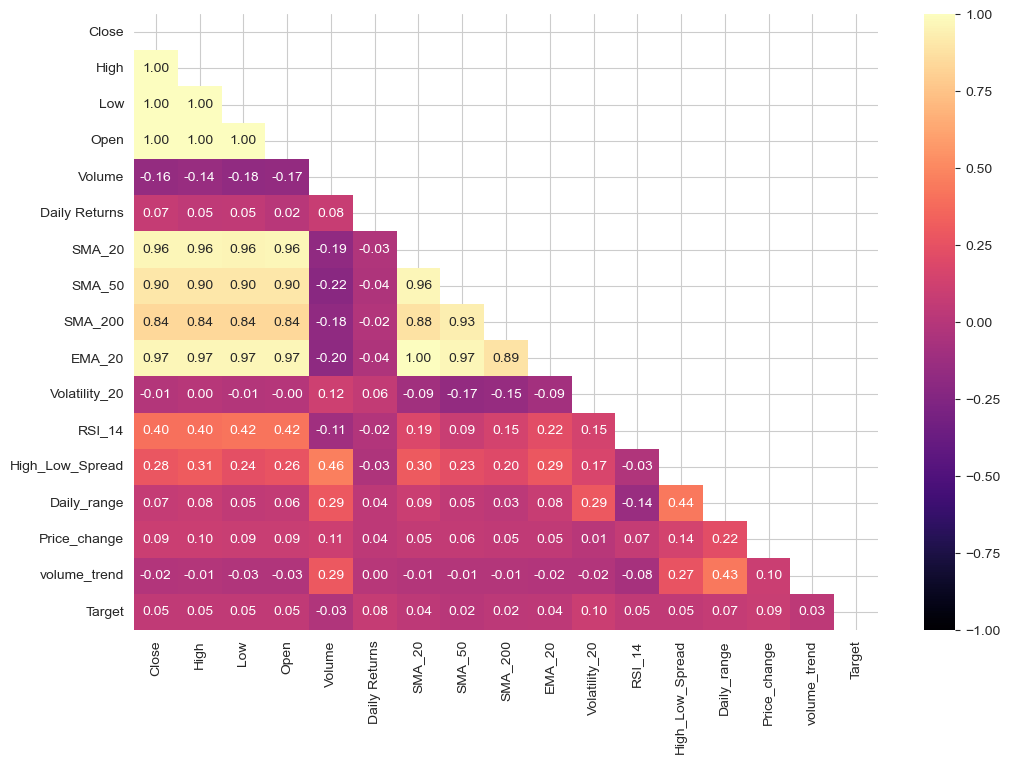

In [147]:
correlation = df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
fig = plt.figure(figsize=(12,8))
sns.heatmap(correlation,mask=mask,annot=True,fmt=".2f",cmap="magma",vmin=-1,vmax=1)
plt.show()


In [148]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily Returns', 'SMA_20',
       'SMA_50', 'SMA_200', 'EMA_20', 'Volatility_20', 'RSI_14',
       'High_Low_Spread', 'Daily_range', 'Price_change', 'volume_trend',
       'Target'],
      dtype='object')


In [ ]:
correlated_features = ["Close","Price_change",""]

In [131]:
# ===============
# Data splitiing ==> Avoids Data leakage 
# ===============
X = df.drop(columns="Target", axis=1)
y = df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.3, random_state= 42, shuffle= False)

In [ ]:
# ==================
# Scaling the Dataset 
# ==================

scale = StandardScaler()
x_train_scaled = scale.fit_transform(X_train)
x_test_scaled = scale.transform(X_test)

mm_scale = MinMaxScaler()
x_train_mm_scale = mm_scale.fit_transform(X_train)
x_test_mm_scale = mm_scale.transform(X_test)

In [ ]:
# =================
# 😎 Random forest Classification pipeline
# =================

pipeline_random = Pipeline([
    ("Scale",MinMaxScaler()),
    ("classifier",RandomForestClassifier())
])

grid_para_rs = {
    "classifier__n_estimators": [100,125,150,175,200],
    "classifier__max_depth":[3,5,7,9,12],
    "classifier__bootstrap":[True],
    
}
tscv = TimeSeriesSplit(n_splits=5)
grid_rf = GridSearchCV(pipeline_random, grid_para_rs,cv=tscv, n_jobs=-1, scoring="accuracy")

grid_rf.fit(X_train,y_train)
y_pre_rf = grid_rf.predict(X_test)
print(f"the best Parameters{grid_rf.best_params_}")
print(f"The best estimator:{grid_rf.best_estimator_}")
print(f"The best score: {grid_rf.best_score_:0.4f}")
print(classification_report(y_test, y_pre_rf))


In [ ]:
# ========================
# Pipelines StandardScaler and SVC
# ========================

pipeline_std = Pipeline([
    ("scale",StandardScaler()),
    ("classifier",SVC()),])

param_grid_ss = {"classifier__C":[0.1,1,5,10],
              "classifier__kernel":["linear", "rbf"]}

grid_ss = GridSearchCV(pipeline_std,
                    param_grid_ss,
                    cv=10,
                    n_jobs=-1,
                    scoring="accuracy")
grid_ss.fit(X_train, y_train)

y_pre_ss = grid_ss.predict(X_test)

print(f"the best Parameters{grid_ss.best_params_}")
print(f"The best estimator:{grid_ss.best_estimator_}")
print(f"The best score: {grid_ss.best_score_:0.4f}")
print(classification_report(y_test,y_pre_ss))

In [ ]:
# =================
# logistic Regresion Pipeline 
# ========================

pipeline_log = Pipeline([
    ("scale",StandardScaler()),
    ("classifier",LogisticRegression(solver="liblinear"))
    ])

param_grid_log = {
    "classifier__max_iter":[100,250,450,500,750,1000],
    "classifier__class_weight":["balanced",None],
    "classifier__penalty" :["l1", "l2"]
}
tscv = TimeSeriesSplit(n_splits=5)
grid_lr = GridSearchCV(pipeline_log,
                       param_grid_log,
                       cv=tscv,
                       n_jobs=-1,
                       scoring="accuracy")

# Fitting the Logisteic regression Model:
grid_lr.fit(X_train, y_train)
y_pre_lr = grid_lr.predict(X_test)
print(classification_report(y_test,y_pre_lr))

In [ ]:
pipeline_des = Pipeline([
    ("classifier",DecisionTreeClassifier())
])


param_grid_dt = {
    "classifier__max_depth":[2,5,7,9,None],
    "classifier__criterion":["gini","entropy","log_loss"],
    "classifier__splitter":["best","random"],
    "classifier__ccp_alpha":[0.0, 0.01, 0.02, 0.05],
    "classifier__class_weight":["balanced",None],
}
tscv = TimeSeriesSplit(n_splits=5)
grid_dt = GridSearchCV(pipeline_des,
                       param_grid_dt,
                       cv=tscv,
                       n_jobs=-1,
                       scoring="accuracy")

grid_dt.fit(X_train, y_train)
y_pre_dt = grid_dt.predict(X_test)
print(classification_report(y_test, y_pre_dt))
print(grid_dt.best_score_)
print(grid_dt.best_params_)

In [ ]:
#AdaBoost and GradientBoost

pipeline_ada = Pipeline([
    ("scale",StandardScaler()),
    ("Adaboost",AdaBoostClassifier())
])


param_grid_ada = {
    "Adaboost__n_estimators":[10,25,50,75,100,150,200],
    "Adaboost__learning_rate":[0.01,0.1,1,10],
}
tscv = TimeSeriesSplit(n_splits=5)

grid_Ada = GridSearchCV(
    pipeline_ada,
    param_grid_ada,
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    scoring="accuracy")


grid_Ada.fit(X_train,y_train)
y_pre_ada = grid_Ada.predict(X_test)
print(classification_report(y_test,y_pre_ada))

In [ ]:
pipeline_GB = Pipeline([
    ("scale",StandardScaler()),
    ("GradientBoost",GradientBoostingClassifier())
])

param_grid_GB = {
    "GradientBoost__loss": ["log_loss"],  
    "GradientBoost__learning_rate": [0.01, 0.1],
    "GradientBoost__n_estimators": [100, 150, 200],
    "GradientBoost__max_depth": [3, 5], 
    "GradientBoost__subsample": [0.8, 1.0], 
    "GradientBoost__max_features": ["sqrt", "log2"], 
    "GradientBoost__min_samples_split": [2, 5],
    "GradientBoost__min_samples_leaf": [1, 3],
}
tscv = TimeSeriesSplit(n_splits=5)
grid_GB = GridSearchCV(
    pipeline_GB,
    param_grid_GB,
    cv=tscv,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1)

grid_GB.fit(X_train,y_train)
y_pre_GB = grid_GB.predict(X_test)
print(classification_report(y_test, y_pre_GB))

In [ ]:
# Here we create our numerical values and split our data one more time 😭😭
df["Target-return"] = df["Close"].pct_change().shift(-1) * 100
 
 
X_reg = df.drop(columns=["Target", "Target-return"],axis=1)
y_reg = df["Target-return"].dropna() 


split_inx = int(0.7 * len(X_reg))

X_reg_train , X_reg_test  =  X_reg[:split_inx] , X_reg[split_inx:]
y_reg_train , y_reg_test  =  y_reg[:split_inx] , y_reg[split_inx:]



In [ ]:
# Create regression Model
# Linear regressio Model
x_reg_train_scaled = scale.fit_transform(X_reg_train)
x_reg_test_scaled= scale.transform(X_reg_test)
model = LinearRegression()
model.fit(x_reg_train_scaled, y_reg_train)

y_pre_OLS = model.predict(x_reg_test_scaled)

print(r2_score(y_reg_test,y_pre_OLS))
print(f"The coeficient is {model.coef_}")
print(f"The model intercept:{model.intercept_}")
print(model.score(x_reg_test_scaled,y_reg_test))

In [ ]:
# Regularization Lasso and Ridge + elstic

model_lasso = Lasso(alpha=(0.1))
model_lasso.fit(x_reg_train_scaled , y_reg_train)
y_pre = model_lasso.predict(x_reg_test_scaled)

In [ ]:
cs_dt = confusion_matrix(y_test, y_pre_rf)
sns.heatmap(cs_dt,annot=True,cmap="Blues",fmt="d",cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
cm_dt = confusion_matrix(y_test, y_pre_dt)
sns.heatmap(cm_dt, annot=True,fmt="d",cmap="Blues",cbar=False)
plt.title("Decision Tree Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
# Interactive Open Price Plot
fig = px.line(df,
              x=df.index,
              y="Open",
              title="AAPL Opening Price Over Time",
              labels={"Open":"Opened Price", "index":"Date"},
              line_shape="linear")

# Customize line color and width
fig.update_traces(line=dict(color="navy", width=2))

# Show interactive plot
fig.show()


In [ ]:


# Interactive Close Price Plot
fig = px.line(df,
              x=df.index,
              y="Close",
              title="AAPL Closing Price Over Time",
              labels={"Close":"Closed Price", "index":"Date"},
              line_shape="linear")

# Customize line color and width
fig.update_traces(line=dict(color="navy", width=2))

# Show interactive plot
fig.show()


In [ ]:
# Convert index to Series for concatenation
dates = pd.Series(df.index)

# Create interactive figure
fig = go.Figure()

# High line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['High'],
    mode='lines',
    name='High',
    line=dict(color='green', width=2)
))

# Low line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Low'],
    mode='lines',
    name='Low',
    line=dict(color='red', width=2)
))

# Shaded area between High and Low
fig.add_trace(go.Scatter(
    x=pd.concat([dates, dates[::-1]]),
    y=pd.concat([df['High'], df['Low'][::-1]]),
    fill='toself',
    fillcolor='lightgreen',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    showlegend=False
))

# Layout
fig.update_layout(
    title="AAPL High-Low Daily Range",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    hovermode="x unified"
)

fig.show()


In [ ]:
# Interactive Volume Plot
fig = px.line(df,
              x=df.index,
              y="Volume",
              title="AAPL Trading Volume Over Time",
              labels={"Volume":"Volume", "index":"Date"},
              line_shape="linear")

# Customize line color and width
fig.update_traces(line=dict(color="navy", width=2))

# Show interactive plot
fig.show()


In [ ]:
fig = px.line(
    df,
    x=df.index,
    y="Daily Returns",
    title="AAPL Daily Returns Over Time",
    labels={"Daily Return": "Daily Return (%)"},
    template="plotly_dark")
fig.show()

In [ ]:
# ===============================
# Part 1: Exploratory Data Analysis
# ===============================

# Set seaborn style
sns.set_style("whitegrid")

# 1️⃣ Plot distribution of Daily Returns
plt.figure(figsize=(12,5))
sns.histplot(df['Daily Returns'].dropna(), bins=50, kde=True, color='navy')
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

In [ ]:

# 3️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[['Close', 'Daily Returns', 'Volatility_20', 'RSI_14', 'High_Low_Spread']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:

# 1️⃣ Close Price
fig = px.line(df, x=df.index, y='Close',
              title='AAPL Close Price Over Time',
              labels={'Close':'Price (USD)'},
              template='plotly_dark')
fig.show()

# 2️⃣ Daily Returns
fig = px.line(df, x=df.index, y='Daily Returns',
              title='AAPL Daily Returns Over Time',
              labels={'Daily Returns':'Daily Return (%)'},
              template='plotly_dark')
fig.show()

# 3️⃣ Moving Averages
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Close'], name='Close', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_20'], name='SMA 20', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_50'], name='SMA 50', line=dict(color='green')))
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_200'], name='SMA 200', line=dict(color='red')))
fig.update_layout(title='AAPL Close Price with Moving Averages',
                  xaxis_title='Date', yaxis_title='Price (USD)', hovermode='x unified')
fig.show()

# 4️⃣ High-Low Range - FIXED VERSION
fig = go.Figure()

# Add High and Low lines
fig.add_trace(go.Scatter(x=df.index, y=df['High'], name='High', line=dict(color='green')))
fig.add_trace(go.Scatter(x=df.index, y=df['Low'], name='Low', line=dict(color='red')))

# Create filled area between High and Low - FIXED
# Convert index to Series for concatenation
dates_forward = pd.Series(df.index)
dates_backward = pd.Series(df.index[::-1])  # Reverse for the "closing" the shape

# Concatenate dates and values properly
filled_dates = pd.concat([dates_forward, dates_backward])
filled_values = pd.concat([df['High'], df['Low'][::-1]])

fig.add_trace(go.Scatter(
    x=filled_dates,
    y=filled_values,
    fill='toself',
    fillcolor='rgba(173, 216, 230, 0.3)',  # Light blue with transparency
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    showlegend=False,
    name='High-Low Range'
))

fig.update_layout(title="AAPL High-Low Daily Range",
                  xaxis_title="Date", yaxis_title="Price (USD)", 
                  hovermode="x unified")
fig.show()

In [ ]:
df_plot = df.iloc[y_test.index].copy()
df_plot["Predicted_SVC"] = y_pre_ss

fig = px.scatter(df_plot,
                 x= y_test.index,
                 y=["Target","Predicted_SVC"],
                 labels={"value":"Target",
                         "Variable":"Legend"},
                 title="SVC Predictions vs Actual Target",
                 template="plotly_white")

fig.show()

In [ ]:
fig = px.bar(df_plot,
             x=y_test.index,
             y=["Target","Predicted_SVC"],
             labels={"value":"Target",
                     "Variable":"Legend"},
             title="SVC Prediction vs actual Target",
             template="plotly_white")

fig.show()

In [ ]:
print("Target distribution:")
print(y_train.value_counts())
print("\nTest distribution:")
print(y_test.value_counts())